# Training vs Generated Data Analysis

Compares aggregate statistics, distributions and temporal structure between:
- **Reference**: the first `TRAINING_DATASET_SIZE` CSVs from the training directory (sorted)
- **Generated**: all CSVs produced by the reverse-diffusion model

Both datasets are either log-prices or log-returns.
Reference paths may be full-length stock histories; generated paths are fixed-length windows.

In [168]:
# ── USER INPUTS ───────────────────────────────────────────────────────────────
REF_DIRECTORY         = "../data/replication_returns_other_gbm"          # training data folder
GEN_DIRECTORY         = "../data/generated/replication/ODE_GBM_NO_NO_REPL_UNCO_ep-239_sde-ve_noise-exponential_20260511_104210_N2000_seed50"
SEED                  = 50
TRAINING_SEED         = 50    # must match config["train"]["seed"] used during training
VAL_SPLIT_RATIO       = 0.05 # set to e.g. 0.1 if --val_split_ratio was used; else None
TRAINING_DATASET_SIZE = None   # number of sliding windows — mirrors --train_subset_size
                               # set to None to use all available (post-val) windows
SEQ_LEN               = 2048  # window length used during training (--seq_len)
STRIDE                = 400   # stride used during training (--stride)
SDE_TYPE              = "gbm"  # "ve", "vp", "subvp", or "gbm"; set "gbm" when trained on cumulative log returns
# ─────────────────────────────────────────────────────────────────────────────

In [169]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats as scipy_stats
from statsmodels.tsa.stattools import acf as sm_acf

np.random.seed(SEED)
rng = np.random.default_rng(SEED)

print(f"REF_DIRECTORY         : {REF_DIRECTORY}")
print(f"GEN_DIRECTORY         : {GEN_DIRECTORY}")
print(f"SEED                  : {SEED}")
print(f"TRAINING_DATASET_SIZE : {TRAINING_DATASET_SIZE}")
print(f"SEQ_LEN               : {SEQ_LEN}")
print(f"STRIDE                : {STRIDE}")

REF_DIRECTORY         : ../data/replication_returns_other_gbm
GEN_DIRECTORY         : ../data/generated/replication/ODE_GBM_NO_NO_REPL_UNCO_ep-239_sde-ve_noise-exponential_20260511_104210_N2000_seed50
SEED                  : 50
TRAINING_DATASET_SIZE : None
SEQ_LEN               : 2048
STRIDE                : 400


## 1. Load data

In [170]:
# ── Reference data ────────────────────────────────────────────────────────────
# Mirrors csdi_train_modified.py exactly:
#   1. Load ALL sorted CSVs — no file cap
#   2. Extract sliding windows with same SEQ_LEN / STRIDE / drop_incomplete=True
#   3. Replicate torch.randperm(seed) + val split + train_subset_size
import torch

ref_csv_files = sorted(Path(REF_DIRECTORY).glob("*.csv"))
if len(ref_csv_files) == 0:
    raise FileNotFoundError(f"No CSV files found in: {REF_DIRECTORY}")

all_windows: list[np.ndarray] = []
n_skipped_short = 0
for fp in ref_csv_files:
    # print(fp)
    df = pd.read_csv(fp, parse_dates=["date"], dayfirst=True)
    df = df.sort_values("date").reset_index(drop=True)
    series = df["log_adj_close"].values.astype(np.float64)
    T = len(series)
    max_start = T - SEQ_LEN
    if max_start < 0:   # shorter than SEQ_LEN — skip (drop_incomplete=True)
        n_skipped_short += 1
        continue
    for s in range(0, max_start + 1, STRIDE):
        all_windows.append(series[s : s + SEQ_LEN])

if n_skipped_short:
    print(f"[WARNING] {n_skipped_short} file(s) shorter than SEQ_LEN={SEQ_LEN} were skipped.")
if len(all_windows) == 0:
    raise RuntimeError("No windows could be extracted. Check SEQ_LEN / STRIDE / REF_DIRECTORY.")

print(f"Total windows in full dataset : {len(all_windows)} "
      f"(from {len(ref_csv_files) - n_skipped_short} usable file(s), "
      f"SEQ_LEN={SEQ_LEN}, STRIDE={STRIDE})")

# ── Replicate training subset selection with torch RNG ────────────────────────
torch_rng  = torch.Generator().manual_seed(TRAINING_SEED)
all_indices = torch.randperm(len(all_windows), generator=torch_rng).tolist()

# Carve out val split first (mirrors val_split_ratio logic in training script)
if VAL_SPLIT_RATIO is not None:
    val_size   = max(1, int(len(all_windows) * VAL_SPLIT_RATIO))
    train_pool = all_indices[val_size:]
    print(f"Val split : {val_size} windows held out (VAL_SPLIT_RATIO={VAL_SPLIT_RATIO})")
else:
    train_pool = all_indices

# Then take TRAINING_DATASET_SIZE from the remaining pool
if TRAINING_DATASET_SIZE is not None and TRAINING_DATASET_SIZE < len(train_pool):
    train_indices = train_pool[:TRAINING_DATASET_SIZE]
    print(f"Reference : {len(train_indices)} windows "
          f"(TRAINING_DATASET_SIZE={TRAINING_DATASET_SIZE} of {len(train_pool)} in pool)")
else:
    train_indices = train_pool
    if TRAINING_DATASET_SIZE is not None:
        print(f"[WARNING] TRAINING_DATASET_SIZE={TRAINING_DATASET_SIZE} >= pool size "
              f"({len(train_pool)}); using all pool windows.")
    print(f"Reference : {len(train_indices)} windows (full training pool)")

ref_paths = [all_windows[i] for i in train_indices]

assert all(len(w) == SEQ_LEN for w in ref_paths), "Window length mismatch — check SEQ_LEN"
print(f"  All window lengths = {SEQ_LEN}  ✓")

Total windows in full dataset : 5568 (from 210 usable file(s), SEQ_LEN=2048, STRIDE=400)
Val split : 278 windows held out (VAL_SPLIT_RATIO=0.05)
Reference : 5290 windows (full training pool)
  All window lengths = 2048  ✓


In [171]:
print(ref_paths[0][:5], "\n", ref_paths[0][-5:])

[0.09530981 0.08515856 0.07490218 0.08515856 0.09530981] 
 [1.22848388 1.21840019 1.20308037 1.20136384 1.199644  ]


In [172]:
# ── Generated data ────────────────────────────────────────────────────────────
# Load ALL CSV files in GEN_DIRECTORY (no size cap).
# Two formats are supported:
#   (a) Per-sample CSVs  — columns: date, log_adj_close  (one file per path)
#   (b) Wide-format CSV  — columns: sample_idx, start_date, end_date, step_000, step_001, ...
#       (produced by generate_samples.py as "generated_samples.csv")
gen_csv_files = sorted(Path(GEN_DIRECTORY).glob("*.csv"))

if len(gen_csv_files) == 0:
    raise FileNotFoundError(f"No CSV files found in: {GEN_DIRECTORY}")

gen_paths: list[np.ndarray] = []
skipped = 0
for fp in gen_csv_files:
    df = pd.read_csv(fp)
    if "log_adj_close" in df.columns:
        # Format (a): individual per-sample CSV
        gen_paths.append(df["log_adj_close"].values.astype(np.float64))
    else:
        # Format (b): wide-format — each row is one sample path
        step_cols = sorted(
            [c for c in df.columns if c.startswith("step_")],
            key=lambda c: int(c.split("_")[1])
        )
        print(step_cols[999:], f"\n first column: {step_cols[0]}, last column: {step_cols[-1]}")
        if step_cols:
            print(df.head())
            for _, row in df.iterrows():
                gen_paths.append(row[step_cols].values.astype(np.float64))
        else:
            skipped += 1

if skipped:
    print(f"[WARNING] Skipped {skipped} file(s) with unrecognised column layout.")
if len(gen_paths) == 0:
    raise RuntimeError("No valid generated paths could be loaded from GEN_DIRECTORY.")

gen_lens = [len(p) for p in gen_paths]
print(f"Generated: {len(gen_paths)} paths loaded  ({len(gen_csv_files)} CSV file(s) read)")
print(f"  Path lengths — min={min(gen_lens)}  max={max(gen_lens)}  "
      f"median={int(np.median(gen_lens))}")

print(gen_paths[0][:5], "\n", gen_paths[0][-5:])
print(gen_paths[-1][:5], "\n", gen_paths[-1][-5:])

['step_999', 'step_1000', 'step_1001', 'step_1002', 'step_1003', 'step_1004', 'step_1005', 'step_1006', 'step_1007', 'step_1008', 'step_1009', 'step_1010', 'step_1011', 'step_1012', 'step_1013', 'step_1014', 'step_1015', 'step_1016', 'step_1017', 'step_1018', 'step_1019', 'step_1020', 'step_1021', 'step_1022', 'step_1023', 'step_1024', 'step_1025', 'step_1026', 'step_1027', 'step_1028', 'step_1029', 'step_1030', 'step_1031', 'step_1032', 'step_1033', 'step_1034', 'step_1035', 'step_1036', 'step_1037', 'step_1038', 'step_1039', 'step_1040', 'step_1041', 'step_1042', 'step_1043', 'step_1044', 'step_1045', 'step_1046', 'step_1047', 'step_1048', 'step_1049', 'step_1050', 'step_1051', 'step_1052', 'step_1053', 'step_1054', 'step_1055', 'step_1056', 'step_1057', 'step_1058', 'step_1059', 'step_1060', 'step_1061', 'step_1062', 'step_1063', 'step_1064', 'step_1065', 'step_1066', 'step_1067', 'step_1068', 'step_1069', 'step_1070', 'step_1071', 'step_1072', 'step_1073', 'step_1074', 'step_1075',

In [173]:
print(len(gen_paths))
print(gen_paths[0][:5], "\n", gen_paths[0][-5:])

512
[-0.06860971 -0.07050635 -0.06294197 -0.10948639 -0.16110705] 
 [-0.03701794 -0.05854523 -0.0778174  -0.0861816  -0.07947772]


## 2. Aggregate statistics

In [174]:
# ── GBM mode: convert cumulative → log returns ────────────────────────────────
# ref_paths: windows sliced from a cumulative series have p[0] = C_start,
#   not r_1. Fix: convert the FULL series first, then re-extract windows.
# gen_paths: standalone generated paths starting from scratch — convert per-path.
if SDE_TYPE == "gbm":
    # ── Reference: full-series conversion then windowing ──────────────────────
    all_windows_ret:      list[np.ndarray]      = []
    all_windows_ret_meta: list[tuple[str, int]] = []   # (filename, start_row)
    for fp in ref_csv_files:
        df = pd.read_csv(fp, parse_dates=["date"], dayfirst=True)
        df = df.sort_values("date").reset_index(drop=True)
        C = df["log_adj_close"].values.astype(np.float64)
        r = np.empty_like(C)
        r[0]  = C[0]
        r[1:] = C[1:] - C[:-1]
        T = len(r)
        max_start = T - SEQ_LEN
        if max_start < 0:
            continue
        for s in range(0, max_start + 1, STRIDE):
            all_windows_ret.append(r[s : s + SEQ_LEN])
            all_windows_ret_meta.append((fp.name, s))

    ref_paths_cumulative = ref_paths
    ref_paths = [all_windows_ret[i]      for i in train_indices]
    ref_meta  = [all_windows_ret_meta[i] for i in train_indices]
    print(f"[GBM] ref_paths rebuilt: full-series cumulative→returns, then windowed "
          f"({len(ref_paths)} windows of length {SEQ_LEN})")
    print(f"  ref_paths[0][:5] : {ref_paths[0][:5]}")

    # ── Generated: per-path conversion (paths start from scratch) ─────────────
    gen_paths_cumulative = gen_paths
    gen_paths_ret = []
    for p in gen_paths_cumulative:
        r = np.empty_like(p)
        r[0]  = p[0]
        r[1:] = p[1:] - p[:-1]
        gen_paths_ret.append(r)
    gen_paths = gen_paths_ret
    print(f"[GBM] gen_paths converted: per-path cumulative→returns "
          f"({len(gen_paths)} paths of length {len(gen_paths[0])})")
    print(f"  gen_paths[0][:5] : {gen_paths[0][:5]}")

[GBM] ref_paths rebuilt: full-series cumulative→returns, then windowed (5290 windows of length 2048)
  ref_paths[0][:5] : [-0.02000138 -0.01015125 -0.01025638  0.01025638  0.01015125]
[GBM] gen_paths converted: per-path cumulative→returns (512 paths of length 2048)
  gen_paths[0][:5] : [-0.06860971 -0.00189664  0.00756438 -0.04654442 -0.05162066]


In [175]:
print(ref_paths[0][:5], "\n", ref_paths[0][-5:])

[-0.02000138 -0.01015125 -0.01025638  0.01025638  0.01015125] 
 [ 0.00334986 -0.0100837  -0.01531982 -0.00171653 -0.00171984]


In [176]:
def compute_stats(paths: list[np.ndarray], label: str) -> dict:
    flat = np.concatenate(paths)
    incs = flat
    # incs = np.concatenate([np.diff(p) for p in paths if len(p) > 1])
    return {
        "label"            : label,
        "n_paths"          : len(paths),
        "n_values"         : len(flat),
        "mean"             : flat.mean(),
        "std"              : flat.std(),
        "min"              : flat.min(),
        "q01"              : np.quantile(flat, 0.01),
        "q05"              : np.quantile(flat, 0.05),
        "q25"              : np.quantile(flat, 0.25),
        "q50"              : np.quantile(flat, 0.50),
        "q75"              : np.quantile(flat, 0.75),
        "q95"              : np.quantile(flat, 0.95),
        "q99"              : np.quantile(flat, 0.99),
        "max"              : flat.max(),
        "skewness"         : scipy_stats.skew(flat),
        "excess_kurtosis"  : scipy_stats.kurtosis(flat, fisher=True),
        "inc_mean"         : incs.mean(),
        "inc_std"          : incs.std(),
        "inc_min"          : incs.min(),
        "inc_q01"          : np.quantile(incs, 0.01),
        "inc_q99"          : np.quantile(incs, 0.99),
        "inc_max"          : flat.max(),
        "inc_skewness"     : scipy_stats.skew(incs),
        "inc_excess_kurt"  : scipy_stats.kurtosis(incs, fisher=True),
    }

ref_stats = compute_stats(ref_paths, "Reference (training)")
gen_stats = compute_stats(gen_paths, "Generated")

# ── Levels table ──────────────────────────────────────────────────────────────
level_keys = ["n_paths", "n_values", "mean", "std", "min", "q01", "q05",
              "q25", "q50", "q75", "q95", "q99", "max", "skewness", "excess_kurtosis"]
df_levels = pd.DataFrame(
    {k: {"Reference": ref_stats[k], "Generated": gen_stats[k]} for k in level_keys}
).T.round(4)

print("=" * 60)
print("  LOG_ADJ_CLOSE  —  Aggregate statistics (levels)")
print("=" * 60)
display(df_levels.style.format("{:.4f}"))

  LOG_ADJ_CLOSE  —  Aggregate statistics (levels)


,Reference,Generated
n_paths,5290.0000,512.0000
n_values,10833920.0000,1048576.0000
mean,0.0005,0.0000
std,0.0208,0.0225
min,-0.9363,-1.7117
q01,-0.0562,-0.0557
q05,-0.0291,-0.0348
q25,-0.0086,-0.0130
q50,0.0000,0.0001
q75,0.0095,0.0131


In [177]:
# ── GBM mode: aggregate statistics on cumulative log returns ──────────────────
if SDE_TYPE == "gbm":
    cum_ref_stats = compute_stats(ref_paths_cumulative, "Reference (cumulative log returns)")
    cum_gen_stats = compute_stats(gen_paths_cumulative, "Generated (cumulative log returns)")

    level_keys = ["n_paths", "n_values", "mean", "std", "min", "q01", "q05",
                  "q25", "q50", "q75", "q95", "q99", "max", "skewness", "excess_kurtosis"]
    df_cum_levels = pd.DataFrame(
        {k: {"Reference (cumulative)": cum_ref_stats[k],
             "Generated (cumulative)": cum_gen_stats[k]}
         for k in level_keys}
    ).T.round(4)

    inc_keys = ["inc_mean", "inc_std", "inc_min", "inc_q01", "inc_q99",
                "inc_max", "inc_skewness", "inc_excess_kurt"]
    rename = {
        "inc_mean": "mean", "inc_std": "std", "inc_min": "min",
        "inc_q01": "q01", "inc_q99": "q99", "inc_max": "max",
        "inc_skewness": "skewness", "inc_excess_kurt": "excess_kurtosis",
    }
    df_cum_incs = pd.DataFrame(
        {rename[k]: {"Reference (cumulative)": cum_ref_stats[k],
                     "Generated (cumulative)": cum_gen_stats[k]}
         for k in inc_keys}
    ).T.round(6)

    print("=" * 60)
    print("  CUMULATIVE LOG RETURNS — Aggregate statistics (levels)")
    print("=" * 60)
    display(df_cum_levels.style.format("{:.4f}"))

    print("=" * 60)
    print("  CUMULATIVE LOG RETURNS — Increments ΔC_t = C_t − C_{t−1}")
    print("=" * 60)
    display(df_cum_incs.style.format("{:.4f}"))

  CUMULATIVE LOG RETURNS — Aggregate statistics (levels)


,Reference (cumulative),Generated (cumulative)
n_paths,5290.0000,512.0000
n_values,10833920.0000,1048576.0000
mean,2.9051,-0.0029
std,1.8671,0.0922
min,-4.1366,-1.4617
q01,-0.6147,-0.2282
q05,0.0049,-0.1541
q25,1.4888,-0.0621
q50,2.8471,-0.0021
q75,4.2355,0.0575


  CUMULATIVE LOG RETURNS — Increments ΔC_t = C_t − C_{t−1}


,Reference (cumulative),Generated (cumulative)
mean,2.9051,-0.0029
std,1.8671,0.0922
min,-4.1366,-1.4617
q01,-0.6147,-0.2282
q99,7.2906,0.2141
max,10.2035,1.6804
skewness,0.2004,-0.0891
excess_kurtosis,-0.3726,0.8095


In [178]:
for paths, label in [(ref_paths, "Reference"), (gen_paths, "GenWerated")]:
    flat = np.concatenate(paths)
    zero_pct = 100.0 * np.mean(flat == 0.0)
    print(f"{label}: {zero_pct:.4f}% absolute zeros ({(flat == 0.0).sum()} / {len(flat)})")


Reference: 7.1735% absolute zeros (777169 / 10833920)
GenWerated: 0.0000% absolute zeros (0 / 1048576)


In [179]:
# ── Increments table ──────────────────────────────────────────────────────────
inc_keys = ["inc_mean", "inc_std", "inc_min", "inc_q01", "inc_q99",
            "inc_max", "inc_skewness", "inc_excess_kurt"]
rename = {
    "inc_mean": "mean", "inc_std": "std", "inc_min": "min",
    "inc_q01": "q01", "inc_q99": "q99", "inc_max": "max",
    "inc_skewness": "skewness", "inc_excess_kurt": "excess_kurtosis",
}
df_incs = pd.DataFrame(
    {rename[k]: {"Reference": ref_stats[k], "Generated": gen_stats[k]}
     for k in inc_keys}
).T.round(6)

print("=" * 60)
print("  INCREMENTS  ΔX_t = X_t − X_{t−1}  —  Aggregate statistics")
print("=" * 60)
display(df_incs.style.format("{:.4f}"))

  INCREMENTS  ΔX_t = X_t − X_{t−1}  —  Aggregate statistics


,Reference,Generated
mean,0.0005,0.0000
std,0.0208,0.0225
min,-0.9363,-1.7117
q01,-0.0562,-0.0557
q99,0.0583,0.0555
max,0.6931,1.7584
skewness,-0.5387,-0.0413
excess_kurtosis,36.0632,109.3641


## 2b. Aggregate statistics — full stock series vs generated

In [180]:
# Load full stock series from REF_DIRECTORY (one per stock, no windowing)
ref_full_paths = []
for fp in sorted(Path(REF_DIRECTORY).glob("*.csv")):
    series = pd.read_csv(fp)["log_adj_close"].values.astype(np.float64)
    ref_full_paths.append(series)

print(f"Full stock series loaded : {len(ref_full_paths)}")
print(f"Lengths — min={min(len(s) for s in ref_full_paths)}  "
      f"max={max(len(s) for s in ref_full_paths)}  "
      f"mean={np.mean([len(s) for s in ref_full_paths]):.0f}")

ref_full_stats = compute_stats(ref_full_paths, "Reference (full series)")

# ── Levels table ──────────────────────────────────────────────────────────────
level_keys = ["n_paths", "n_values", "mean", "std", "min", "q01", "q05",
              "q25", "q50", "q75", "q95", "q99", "max", "skewness", "excess_kurtosis"]
df_levels_full = pd.DataFrame(
    {k: {"Reference (full)": ref_full_stats[k], "Generated": gen_stats[k]} for k in level_keys}
).T.round(4)

print("\n" + "=" * 60)
print("  LOG_ADJ_CLOSE  —  Aggregate statistics (levels)")
print("=" * 60)
display(df_levels_full.style.format("{:.4f}"))

# ── Increments table ──────────────────────────────────────────────────────────
inc_keys = ["inc_mean", "inc_std", "inc_min", "inc_q01", "inc_q99",
            "inc_max", "inc_skewness", "inc_excess_kurt"]
rename = {
    "inc_mean": "mean", "inc_std": "std", "inc_min": "min",
    "inc_q01": "q01", "inc_q99": "q99", "inc_max": "max",
    "inc_skewness": "skewness", "inc_excess_kurt": "excess_kurtosis",
}
df_incs_full = pd.DataFrame(
    {rename[k]: {"Reference (full)": ref_full_stats[k], "Generated": gen_stats[k]}
     for k in inc_keys}
).T.round(6)

print("\n" + "=" * 60)
print("  INCREMENTS  ΔX_t = X_t − X_{t−1}  —  Aggregate statistics")
print("=" * 60)
display(df_incs_full.style.format("{:.4f}"))

Full stock series loaded : 210
Lengths — min=10083  max=16175  mean=12493

  LOG_ADJ_CLOSE  —  Aggregate statistics (levels)


,Reference (full),Generated
n_paths,210.0000,512.0000
n_values,2623490.0000,1048576.0000
mean,2.9407,0.0000
std,2.0388,0.0225
min,-4.1366,-1.7117
q01,-0.6926,-0.0557
q05,-0.1024,-0.0348
q25,1.3002,-0.0130
q50,2.8820,0.0001
q75,4.4243,0.0131



  INCREMENTS  ΔX_t = X_t − X_{t−1}  —  Aggregate statistics


,Reference (full),Generated
mean,2.9407,0.0000
std,2.0388,0.0225
min,-4.1366,-1.7117
q01,-0.6926,-0.0557
q99,7.6156,0.0555
max,10.2664,1.7584
skewness,0.2212,-0.0413
excess_kurtosis,-0.5445,109.3641


## Per-window statistics

In [181]:
def per_window_stats(paths: list[np.ndarray]) -> pd.DataFrame:
    rows = []
    for p in paths:
        incs = np.diff(p)
        rows.append({
            "mean"         : float(p.mean()),
            "std"          : float(p.std()),
            "skewness"     : float(scipy_stats.skew(p)),
            "excess_kurt"  : float(scipy_stats.kurtosis(p, fisher=True)),
            "zero_ratio"   : float(np.mean(p == 0.0)),
            "inc_std"      : float(incs.std()),
            "inc_skewness" : float(scipy_stats.skew(incs)),
            "inc_excess_kurt": float(scipy_stats.kurtosis(incs, fisher=True)),
        })
    return pd.DataFrame(rows)

ref_pw = per_window_stats(ref_paths)
gen_pw = per_window_stats(gen_paths)

# ── Summary table: mean ± std of each per-window stat ────────────────────────
summary = pd.DataFrame({
    "Reference  mean": ref_pw.mean(),
    "Reference  std" : ref_pw.std(),
    "Generated  mean": gen_pw.mean(),
    "Generated  std" : gen_pw.std(),
}).round(5)
print("Per-window statistics — summary (mean ± std across windows)")
display(summary.style.format("{:.4f}"))

# ── Violin plots ──────────────────────────────────────────────────────────────
metrics = list(ref_pw.columns)
fig, axes = plt.subplots(2, 4, figsize=(16, 7))

for ax, metric in zip(axes.flat, metrics):
    data  = [ref_pw[metric].values, gen_pw[metric].values]
    parts = ax.violinplot(data, positions=[0, 1], showmedians=True, showextrema=True)
    parts["bodies"][0].set_facecolor("tab:blue");   parts["bodies"][0].set_alpha(0.55)
    parts["bodies"][1].set_facecolor("tab:orange"); parts["bodies"][1].set_alpha(0.55)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Reference", "Generated"])
    ax.set_title(metric)
    ax.grid(axis="y", linewidth=0.4)

plt.suptitle("Distribution of per-window statistics", y=1.02)
plt.tight_layout()
plt.show()


Per-window statistics — summary (mean ± std across windows)


,Reference mean,Reference std,Generated mean,Generated std
mean,0.0005,0.0004,0.0000,0.0001
std,0.0196,0.0069,0.0221,0.0045
skewness,-0.3403,1.3745,-0.0888,0.4662
excess_kurt,14.0761,36.3552,9.3566,53.2740
zero_ratio,0.0717,0.0936,0.0000,0.0000
inc_std,0.0279,0.0100,0.0348,0.0076
inc_skewness,0.2385,0.4993,-0.0675,1.1824
inc_excess_kurt,11.2795,23.0052,7.8939,56.5364


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_34344\2342577457.py:45: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


### Kurtosis offenders

The top offenders are identified through computation of the increments so as to identify most leptokurtic distribution, which have very fat tails and sharp peaks.

In [182]:
# ── Kurtosis diagnosis: worst windows by increment excess kurtosis ─────────────
TOP_K      = 10   # number of worst windows to inspect
TOP_N_INCS = 5    # largest increments to report per window

def print_worst_kurtosis_windows(pw: pd.DataFrame, paths: list, label: str,
                                  top_k: int, top_n: int) -> None:
    worst = pw.nlargest(top_k, "inc_excess_kurt")
    print(f"{'='*70}")
    print(f"Top-{top_k} {label} windows by increment excess kurtosis")
    print(f"{'='*70}\n")
    for rank, (win_idx, row) in enumerate(worst.iterrows(), start=1):
        path     = paths[win_idx]
        incs     = np.diff(path)
        abs_incs = np.abs(incs)
        print(f"Rank {rank:2d} | window index {win_idx}")
        print(f"  {'mean':<20s}: {row['mean']:+.6f}")
        print(f"  {'std':<20s}: {row['std']:.6f}")
        print(f"  {'skewness':<20s}: {row['skewness']:+.4f}")
        print(f"  {'excess_kurt (levels)':<20s}: {row['excess_kurt']:+.4f}")
        print(f"  {'inc_std':<20s}: {row['inc_std']:.6f}")
        print(f"  {'inc_skewness':<20s}: {row['inc_skewness']:+.4f}")
        print(f"  {'inc_excess_kurt':<20s}: {row['inc_excess_kurt']:+.4f}")
        top_pos = np.argsort(abs_incs)[::-1][:top_n]
        print(f"\n  Top-{top_n} largest |Δx_t|  (position l in [0, {len(incs)-1}]):")
        print(f"  {'l':>6}  {'Δx':>12}  {'|Δx|':>10}  {'x[l]':>12}  {'x[l+1]':>12}")
        for pos in top_pos:
            print(f"  {pos:>6d}  {incs[pos]:>+12.6f}  {abs_incs[pos]:>10.6f}"
                  f"  {path[pos]:>+12.6f}  {path[pos+1]:>+12.6f}")
        print()

print_worst_kurtosis_windows(gen_pw, gen_paths, "Generated", TOP_K, TOP_N_INCS)
print_worst_kurtosis_windows(ref_pw, ref_paths, "Reference", TOP_K, TOP_N_INCS)

Top-10 Generated windows by increment excess kurtosis

Rank  1 | window index 289
  mean                : +0.000096
  std                 : 0.059169
  skewness            : +0.9910
  excess_kurt (levels): +719.9979
  inc_std             : 0.101531
  inc_skewness        : -14.4797
  inc_excess_kurt     : +750.7243

  Top-5 largest |Δx_t|  (position l in [0, 2046]):
       l            Δx        |Δx|          x[l]        x[l+1]
    2005     -3.470132    3.470132     +1.758437     -1.711695
    2006     +1.764734    1.764734     -1.711695     +0.053039
    2004     +1.743239    1.743239     +0.015198     +1.758437
    1510     -0.229659    0.229659     +0.107276     -0.122383
     160     -0.173839    0.173839     +0.074998     -0.098841

Rank  2 | window index 394
  mean                : +0.000061
  std                 : 0.047247
  skewness            : +0.2381
  excess_kurt (levels): +711.0387
  inc_std             : 0.080645
  inc_skewness        : +14.9055
  inc_excess_kurt     : +750

In [183]:
# if TRAINING_DATASET_SIZE > 15 or TRAINING_DATASET_SIZE == 1.0:
# ── Aggregate statistics after removing the N_DROP most leptokurtic windows ───
N_DROP = 15   # number of worst-kurtosis windows to exclude from each dataset

gen_drop_idx = set(gen_pw.nlargest(N_DROP, "inc_excess_kurt").index)
ref_drop_idx = set(ref_pw.nlargest(N_DROP, "inc_excess_kurt").index)

gen_paths_trim = [p for i, p in enumerate(gen_paths) if i not in gen_drop_idx]
ref_paths_trim = [p for i, p in enumerate(ref_paths) if i not in ref_drop_idx]

print(f"Generated : {len(gen_paths)} → {len(gen_paths_trim)} windows "
      f"(removed {len(gen_drop_idx)} most leptokurtic)")
print(f"Reference : {len(ref_paths)} → {len(ref_paths_trim)} windows "
      f"(removed {len(ref_drop_idx)} most leptokurtic)\n")

ref_stats_trim = compute_stats(ref_paths_trim, "Reference (trimmed)")
gen_stats_trim = compute_stats(gen_paths_trim, "Generated (trimmed)")

keys = ["mean", "std", "min", "q01", "q99", "max", "skewness", "excess_kurtosis",
      "inc_mean", "inc_std", "inc_min", "inc_q01", "inc_q99", "inc_max",
      "inc_skewness", "inc_excess_kurt"]

df_cmp = pd.DataFrame({
"Gen  full"   : {k: gen_stats[k]      for k in keys},
"Gen  trimmed": {k: gen_stats_trim[k] for k in keys},
"Ref  full"   : {k: ref_stats[k]      for k in keys},
"Ref  trimmed": {k: ref_stats_trim[k] for k in keys},
}).round(6)

print(f"Aggregate statistics — full vs trimmed (top-{N_DROP} leptokurtic windows removed)")
display(df_cmp.style.format("{:.6f}"))

Generated : 512 → 497 windows (removed 15 most leptokurtic)
Reference : 5290 → 5275 windows (removed 15 most leptokurtic)

Aggregate statistics — full vs trimmed (top-15 leptokurtic windows removed)


,Gen full,Gen trimmed,Ref full,Ref trimmed
mean,0.000012,0.000012,0.000459,0.000460
std,0.022528,0.022119,0.020802,0.020798
min,-1.711695,-0.394029,-0.936258,-0.936258
q01,-0.055720,-0.055524,-0.056155,-0.056193
q99,0.055468,0.055334,0.058261,0.058269
max,1.758437,0.432875,0.693147,0.693147
skewness,-0.041332,-0.077256,-0.538746,-0.487746
excess_kurtosis,109.364053,5.248152,36.063195,34.281046
inc_mean,0.000012,0.000012,0.000459,0.000460
inc_std,0.022528,0.022119,0.020802,0.020798


In [184]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (pw, paths, label, color) in zip(axes, [
    (ref_pw, ref_paths, "Reference", "tab:blue"),
    (gen_pw, gen_paths, "Generated", "tab:orange"),
]):
    worst_idx = pw["inc_excess_kurt"].idxmax()
    p = paths[worst_idx]
    ax.plot(p, linewidth=0.8, color=color)
    ax.set_title(f"{label} — most leptokurtic window\n"
                 f"inc_excess_kurt={pw.loc[worst_idx, 'inc_excess_kurt']:.2f}  "
                 f"idx={worst_idx}")
    ax.set_xlabel("step t")
    ax.set_ylabel("log_adj_close")
    ax.grid(True, linewidth=0.3)

plt.tight_layout()
plt.show()


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_34344\1686780548.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_34344\705125570.py:12: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(1, 2, figsize=(16, 5))


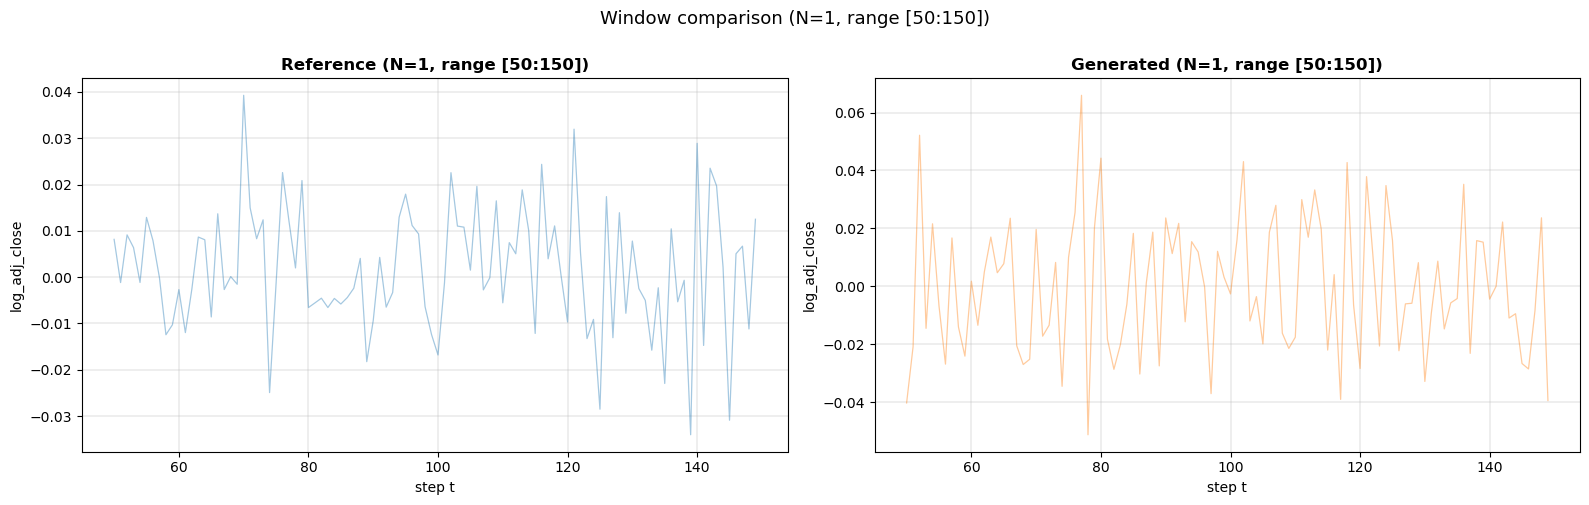

Plotted 1 reference and 1 generated paths
Range: [50:150]


In [185]:
# ── Compare N individual windows with custom range (user-specified) ──────────
N_WINDOWS = 1     # ← change this to select how many paths to visualize
START_IDX = 50       # ← start index (0 = beginning)
END_IDX   = 150   # ← end index (None = full length, or e.g. 500, 1000, etc.)

n_ref = min(N_WINDOWS, len(ref_paths))
n_gen = min(N_WINDOWS, len(gen_paths))

ref_idx = rng.choice(len(ref_paths), size=n_ref, replace=False)
gen_idx = rng.choice(len(gen_paths), size=n_gen, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Reference paths ─────────────────────────────────────────────────────────
ax = axes[0]
for i in ref_idx:
    p = ref_paths[i][START_IDX:END_IDX]
    ax.plot(np.arange(START_IDX, START_IDX + len(p)), p, 
            alpha=0.4, linewidth=0.9, color="tab:blue")
ax.set_title(f"Reference (N={n_ref}, range [{START_IDX}:{END_IDX}])", 
             fontsize=12, fontweight="bold")
ax.set_xlabel("step t")
ax.set_ylabel("log_adj_close")
ax.grid(True, linewidth=0.3)

# ── Generated paths ─────────────────────────────────────────────────────────
ax = axes[1]
for i in gen_idx:
    p = gen_paths[i][START_IDX:END_IDX]
    ax.plot(np.arange(START_IDX, START_IDX + len(p)), p, 
            alpha=0.4, linewidth=0.9, color="tab:orange")
ax.set_title(f"Generated (N={n_gen}, range [{START_IDX}:{END_IDX}])", 
             fontsize=12, fontweight="bold")
ax.set_xlabel("step t")
ax.set_ylabel("log_adj_close")
ax.grid(True, linewidth=0.3)

plt.suptitle(f"Window comparison (N={N_WINDOWS}, range [{START_IDX}:{END_IDX}])", 
             y=1.00, fontsize=13)
plt.tight_layout()
display(fig)
plt.close(fig)
# plt.show()

print(f"Plotted {n_ref} reference and {n_gen} generated paths")
print(f"Range: [{START_IDX}:{END_IDX}]")


## 3. Level distribution: histogram, QQ plot, ECDF

In [186]:
gen_checkpoint_name = os.path.basename(GEN_DIRECTORY.rstrip('/'))
ref_checkpoint_name = os.path.basename(REF_DIRECTORY.rstrip('/'))

Levels KS statistic = 0.0791  |  p-value = 0.0000e+00


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_34344\4268208200.py:12: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(1, 3, figsize=(16, 4))
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_34344\4268208200.py:52: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\Lenovo\anaconda3\envs\thesis\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


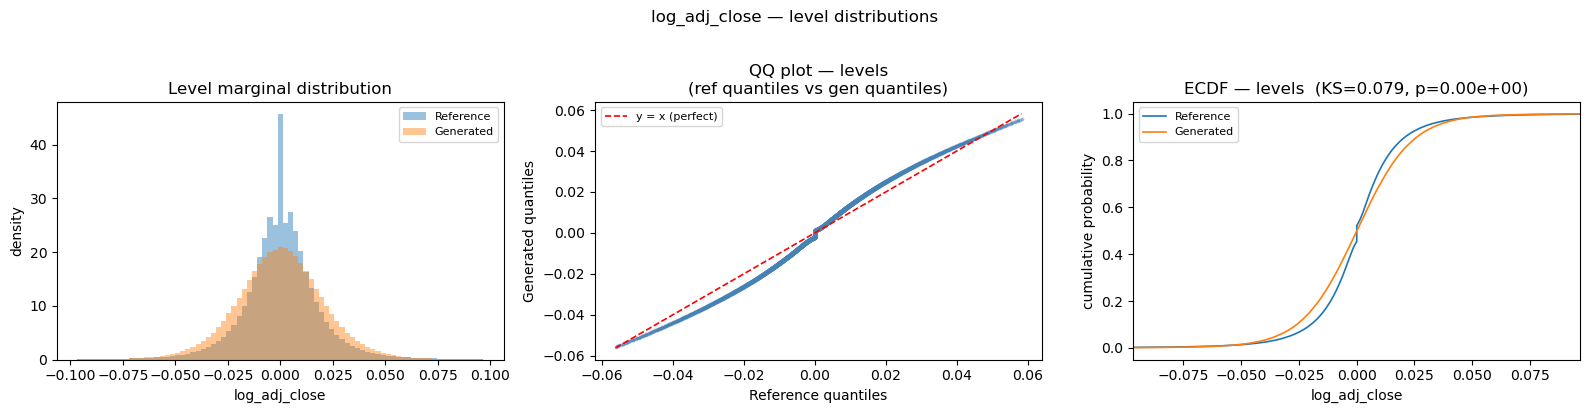

In [187]:
ref_flat = np.concatenate(ref_paths)
gen_flat = np.concatenate(gen_paths)

ks_stat_lev, ks_p_lev = scipy_stats.ks_2samp(ref_flat, gen_flat)
print(f"Levels KS statistic = {ks_stat_lev:.4f}  |  p-value = {ks_p_lev:.4e}")

combined = np.concatenate([ref_flat, gen_flat])
lo, hi   = np.quantile(combined, [0.002, 0.998])
bins     = np.linspace(lo, hi, 80)
xs       = np.linspace(lo, hi, 400)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (a) Histogram / density
ax = axes[0]
ax.hist(ref_flat, bins=bins, density=True, alpha=0.45, label="Reference", color="tab:blue")
ax.hist(gen_flat, bins=bins, density=True, alpha=0.45, label="Generated", color="tab:orange")
ax.set_title("Level marginal distribution")
ax.set_xlabel("log_adj_close")
ax.set_ylabel("density")
ax.legend(fontsize=8)

# (b) Empirical QQ plot (ref quantiles vs gen quantiles)
ax = axes[1]
n_q  = min(len(ref_flat), len(gen_flat), 5_000)
probs = np.linspace(0.01, 0.99, n_q)
q_ref = np.quantile(ref_flat, probs)
q_gen = np.quantile(gen_flat, probs)
ax.scatter(q_ref, q_gen, s=3, alpha=0.4, color="steelblue")
lims = [min(q_ref.min(), q_gen.min()), max(q_ref.max(), q_gen.max())]
ax.plot(lims, lims, "r--", linewidth=1.2, label="y = x (perfect)")
ax.set_title("QQ plot — levels\n(ref quantiles vs gen quantiles)")
ax.set_xlabel("Reference quantiles")
ax.set_ylabel("Generated quantiles")
ax.legend(fontsize=8)

# (c) ECDF
ax = axes[2]
for vals, label, color in [
    (ref_flat, "Reference", "tab:blue"),
    (gen_flat, "Generated", "tab:orange")
]:
    s = np.sort(vals)
    ax.plot(s, np.arange(1, len(s) + 1) / len(s), label=label, linewidth=1.2)
ax.set_xlim(lo, hi)
ax.set_title(f"ECDF — levels  (KS={ks_stat_lev:.3f}, p={ks_p_lev:.2e})")
ax.set_xlabel("log_adj_close")
ax.set_ylabel("cumulative probability")
ax.legend(fontsize=8)

plt.suptitle("log_adj_close — level distributions", y=1.02)
plt.tight_layout()
display(fig)
plt.close(fig)
plt.savefig(f"../images/comparison/level_distributions_comparison_{gen_checkpoint_name}.png", dpi=300)

## 4. Increment distribution: histogram, QQ plot, ECDF

Increments KS statistic = 0.0910  |  p-value = 0.0000e+00


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_34344\639538947.py:51: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\Lenovo\anaconda3\envs\thesis\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


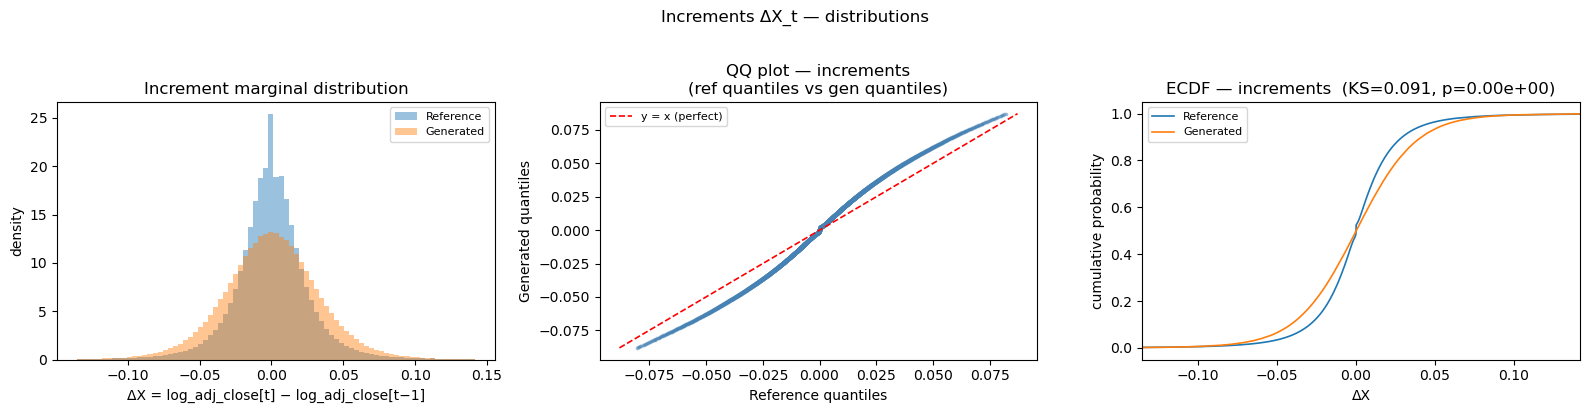

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_34344\639538947.py:55: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [203]:
ref_incs = np.concatenate([np.diff(p) for p in ref_paths if len(p) > 1])
gen_incs = np.concatenate([np.diff(p) for p in gen_paths if len(p) > 1])

ks_stat_inc, ks_p_inc = scipy_stats.ks_2samp(ref_incs, gen_incs)
print(f"Increments KS statistic = {ks_stat_inc:.4f}  |  p-value = {ks_p_inc:.4e}")

combined_inc = np.concatenate([ref_incs, gen_incs])
lo_i, hi_i  = np.quantile(combined_inc, [0.002, 0.998])
bins_i      = np.linspace(lo_i, hi_i, 80)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (a) Histogram / density
ax = axes[0]
ax.hist(ref_incs, bins=bins_i, density=True, alpha=0.45, label="Reference", color="tab:blue")
ax.hist(gen_incs, bins=bins_i, density=True, alpha=0.45, label="Generated", color="tab:orange")
ax.set_title("Increment marginal distribution")
ax.set_xlabel("ΔX = log_adj_close[t] − log_adj_close[t−1]")
ax.set_ylabel("density")
ax.legend(fontsize=8)

# (b) Empirical QQ plot
ax = axes[1]
n_q  = min(len(ref_incs), len(gen_incs), 5_000)
probs = np.linspace(0.01, 0.99, n_q)
q_ref_i = np.quantile(ref_incs, probs)
q_gen_i = np.quantile(gen_incs, probs)
ax.scatter(q_ref_i, q_gen_i, s=3, alpha=0.4, color="steelblue")
lims_i = [min(q_ref_i.min(), q_gen_i.min()), max(q_ref_i.max(), q_gen_i.max())]
ax.plot(lims_i, lims_i, "r--", linewidth=1.2, label="y = x (perfect)")
ax.set_title("QQ plot — increments\n(ref quantiles vs gen quantiles)")
ax.set_xlabel("Reference quantiles")
ax.set_ylabel("Generated quantiles")
ax.legend(fontsize=8)

# (c) ECDF
ax = axes[2]
for vals, label, color in [
    (ref_incs, "Reference", "tab:blue"),
    (gen_incs, "Generated", "tab:orange")
]:
    s = np.sort(vals)
    ax.plot(s, np.arange(1, len(s) + 1) / len(s), label=label, linewidth=1.2)
ax.set_xlim(lo_i, hi_i)
ax.set_title(f"ECDF — increments  (KS={ks_stat_inc:.3f}, p={ks_p_inc:.2e})")
ax.set_xlabel("ΔX")
ax.set_ylabel("cumulative probability")
ax.legend(fontsize=8)

plt.suptitle("Increments ΔX_t — distributions", y=1.02)
plt.tight_layout()
display(fig)
plt.close(fig)
plt.savefig(f"../images/comparison/increments_distributions_comparison_{gen_checkpoint_name}.png", dpi=300)
plt.show()

## 5. Sample paths

Visual check: do the shapes, scale, and fan-out look alike?

Reference paths may be longer; if so, a random window of the generated-path length is
extracted (using `SEED`) for a fair apples-to-apples visual.

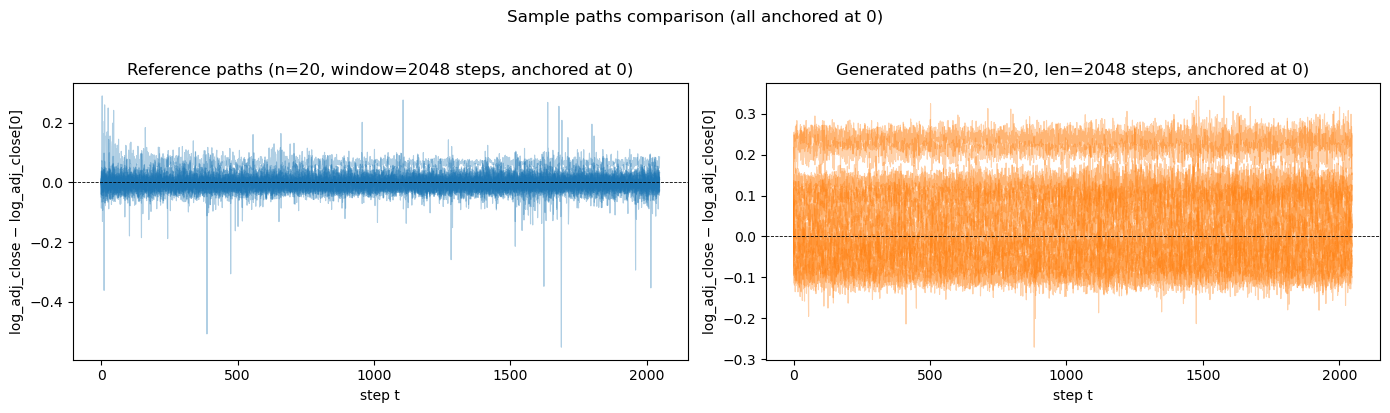

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_34344\564206547.py:45: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [204]:
N_SHOW   = 20
GEN_LEN  = int(np.median(gen_lens))   # typical generated path length

# Sample random paths from each dataset
ref_idx = rng.choice(len(ref_paths), size=min(N_SHOW, len(ref_paths)), replace=False)
gen_idx = rng.choice(len(gen_paths), size=min(N_SHOW, len(gen_paths)), replace=False)

def extract_window(path: np.ndarray, window_len: int, rng: np.random.Generator) -> np.ndarray:
    """Extract a random window of `window_len` from `path`."""
    if len(path) <= window_len:
        return path
    start = rng.integers(0, len(path) - window_len + 1)
    return path[start : start + window_len]

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)

# Reference
ax = axes[0]
for i in ref_idx:
    p = extract_window(ref_paths[i], GEN_LEN, rng)
    p = p - p[0]   # anchor at 0
    ax.plot(np.arange(len(p)), p, alpha=0.35, linewidth=0.8, color="tab:blue")
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.set_title(f"Reference paths (n={len(ref_idx)}, window={GEN_LEN} steps, anchored at 0)")
ax.set_xlabel("step t")
ax.set_ylabel("log_adj_close − log_adj_close[0]")

# Generated
ax = axes[1]
for i in gen_idx:
    p = gen_paths[i]
    p = p - p[0]   # anchor at 0
    ax.plot(np.arange(len(p)), p, alpha=0.35, linewidth=0.8, color="tab:orange")
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.set_title(f"Generated paths (n={len(gen_idx)}, len={GEN_LEN} steps, anchored at 0)")
ax.set_xlabel("step t")
ax.set_ylabel("log_adj_close − log_adj_close[0]")

plt.suptitle("Sample paths comparison (all anchored at 0)", y=1.02)
plt.tight_layout()
display(fig)
plt.close(fig)
plt.savefig
plt.savefig(f"../images/comparison/sample_paths_comparison_{gen_checkpoint_name}.png", dpi=300)
plt.show()

## 6. Autocorrelation: levels vs increments

**Rationale**:
- *Levels*: log-price paths should show high persistence (ACF ≈ 1, slow decay).
- *Increments*: log-returns should be nearly i.i.d. (ACF ≈ 0 at all lags ≥ 1).

We average ACFs across multiple paths for a stable estimate.  
For reference paths longer than `GEN_LEN` we extract the first `GEN_LEN` steps.

In [190]:
# N_ACF_PATHS = min(50, len(ref_paths), len(gen_paths))
# LAGS        = min(30, GEN_LEN // 2)

# def mean_acf_across_paths(
#     paths: list[np.ndarray],
#     n_paths: int,
#     lags: int,
#     use_diff: bool = False,
#     max_len: int | None = None,
#     rng: np.random.Generator | None = None,
# ) -> np.ndarray:
#     """Average ACF (lags 1..lags) across up to `n_paths` paths."""
#     indices = (
#         rng.choice(len(paths), size=n_paths, replace=False)
#         if rng is not None
#         else np.arange(min(n_paths, len(paths)))
#     )
#     acfs = []
#     for i in indices:
#         x = paths[i]
#         if max_len is not None and len(x) > max_len:
#             x = x[:max_len]   # align to generated path length
#         if use_diff:
#             x = np.diff(x)
#         if len(x) <= lags:
#             continue
#         acfs.append(sm_acf(x, nlags=lags, fft=True)[1:])   # skip lag-0 (=1)
#     return np.mean(acfs, axis=0) if acfs else np.zeros(lags)

# lag_axis = np.arange(1, LAGS + 1)

# ref_acf_lev = mean_acf_across_paths(ref_paths, N_ACF_PATHS, LAGS,
#                                     use_diff=False, max_len=GEN_LEN, rng=rng)
# gen_acf_lev = mean_acf_across_paths(gen_paths, N_ACF_PATHS, LAGS,
#                                     use_diff=False, max_len=None, rng=rng)
# ref_acf_inc = mean_acf_across_paths(ref_paths, N_ACF_PATHS, LAGS,
#                                     use_diff=True,  max_len=GEN_LEN, rng=rng)
# gen_acf_inc = mean_acf_across_paths(gen_paths, N_ACF_PATHS, LAGS,
#                                     use_diff=True,  max_len=None, rng=rng)

# fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ax = axes[0]
# ax.plot(lag_axis, ref_acf_lev, label="Reference", color="tab:blue",   linewidth=1.4)
# ax.plot(lag_axis, gen_acf_lev, label="Generated", color="tab:orange", linewidth=1.4)
# ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
# ax.set_title("ACF of levels  (should be ≈ 1, slow decay)")
# ax.set_xlabel("lag")
# ax.set_ylabel("autocorrelation")
# ax.set_ylim(-0.2, 1.05)
# ax.legend(fontsize=9)

# ax = axes[1]
# ax.plot(lag_axis, ref_acf_inc, label="Reference", color="tab:blue",   linewidth=1.4)
# ax.plot(lag_axis, gen_acf_inc, label="Generated", color="tab:orange", linewidth=1.4)
# ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
# ax.set_title("ACF of increments  (should be ≈ 0 at all lags)")
# ax.set_xlabel("lag")
# ax.set_ylabel("autocorrelation")
# ax.set_ylim(-0.3, 1.05)
# ax.legend(fontsize=9)

# plt.suptitle(f"Autocorrelation structure  (avg over {N_ACF_PATHS} paths)", y=1.02)
# plt.tight_layout()
# plt.show()

# print(f"Ref  level  ACF at lag-1: {ref_acf_lev[0]:.3f}  |  "
#       f"Gen  level  ACF at lag-1: {gen_acf_lev[0]:.3f}")
# print(f"Ref  inc    ACF at lag-1: {ref_acf_inc[0]:.3f}  |  "
#       f"Gen  inc    ACF at lag-1: {gen_acf_inc[0]:.3f}")

# 8. Paper's FTS evaluations metrics
These metrics are written to work on **LOG-RETURN**.

In [191]:
sys.path.append(os.path.abspath(".."))

import replication.stylized_facts as sf
import numpy as np

In [208]:
# Reference: windows as log returns (list[np.ndarray])
ref_full_pooled = np.concatenate(ref_paths)
ref_full_obj    = np.empty(len(ref_paths), dtype=object)
for i, r in enumerate(ref_paths):
    ref_full_obj[i] = r

# Generated: already log returns after GBM conversion
gen_paths_arr = np.concatenate(gen_paths)
gen_paths_obj = np.empty(len(gen_paths), dtype=object)
for i, g in enumerate(gen_paths):
    gen_paths_obj[i] = g

In [193]:
# Use sf.distribution() with normalize=True and scale='log'
output_dir = Path("../images/stylized_facts_output_heavy_tails")
output_dir.mkdir(exist_ok=True, parents=True)


In [194]:
print(gen_paths[1][:5], "\n", gen_paths[0][-5:])

[ 0.09074563  0.01824199  0.03415316 -0.05053047  0.01550657] 
 [ 0.01024558 -0.02152728 -0.01927217 -0.0083642   0.00670388]


In [195]:
# Prepare data as object arrays (one array per path)
# ref_paths_arr = np.array(ref_paths, dtype=object)
# gen_paths_arr = np.array(gen_paths, dtype=object)

# Using np.concatenate
# ref_paths_arr = np.concatenate(ref_paths)
gen_paths_arr = np.concatenate(gen_paths)

# If ref_paths and gen_paths are lists:
# ref_paths_obj = np.empty(len(ref_paths), dtype=object)
# for i, r in enumerate(ref_paths):
#     ref_paths_obj[i] = r

gen_paths_obj = np.empty(len(gen_paths), dtype=object)
for i, g in enumerate(gen_paths):
    gen_paths_obj[i] = g

# Extract checkpoint names (last part after "/")
gen_checkpoint_name = os.path.basename(GEN_DIRECTORY.rstrip('/'))
ref_checkpoint_name = os.path.basename(REF_DIRECTORY.rstrip('/'))

In [196]:
# # print(ref_paths[:5], "\n", ref_paths.shape)
# print(ref_paths_arr[:5],"\n", ref_paths_arr.shape)
print(gen_paths_obj[:5],"\n", gen_paths_obj.shape)

[array([-0.06860971, -0.00189664,  0.00756438, ..., -0.01927217,
        -0.0083642 ,  0.00670388])
 array([ 0.09074563,  0.01824199,  0.03415316, ..., -0.00609201,
        -0.00497279,  0.00413198])
 array([-0.02594215,  0.05320118,  0.00196436, ...,  0.00154556,
        -0.01892181,  0.00384862])
 array([-0.07007515, -0.06472805,  0.0232497 , ..., -0.05100695,
        -0.01211982, -0.00776091])
 array([-0.10042378,  0.00773106, -0.00711114, ..., -0.01333262,
         0.01434454,  0.01555001])                              ] 
 (512,)


In [210]:
sf.distribution(
    ref_full_pooled,
    file_name=str(output_dir / f"generated_distribution_{ref_checkpoint_name}"),
    scale="log",
    multiple=False,
    normalize=True,
    granuality=100,
)

In [211]:
sf.distribution(
    gen_paths_arr,
    file_name=str(output_dir / f"generated_distribution_{gen_checkpoint_name}"),
    scale="log",
    multiple=False,
    normalize=True,
    granuality=100,
)

In [212]:
sf.acf(
    ref_full_obj,
    file_name=str(output_dir / f"reference_volatility_clustering_{ref_checkpoint_name}"),
    for_abs=True,
    multiple=True,
    fit=False,
    scale="log",
    max_lag=1000,
)


KeyboardInterrupt: 

In [213]:
sf.acf(
    gen_paths_obj,
    file_name=str(output_dir / f"generated_volatility_clustering__{gen_checkpoint_name}"),
    for_abs=True,
    multiple=True,
    fit=False,
    scale="log",
    max_lag=1000,
)

In [214]:
ref_lev = sf.leverage_effect(
    ref_full_obj,
    file_name=str(output_dir / f"reference_leverage_effect_{ref_checkpoint_name}"),
    multiple=True,
    min_lag=1,
    max_lag=100,
)

gen_lev = sf.leverage_effect(
    gen_paths_obj,
    file_name=str(output_dir / f"generated_leverage_effect_{gen_checkpoint_name}"),
    multiple=True,
    min_lag=1,
    max_lag=100,
)


In [216]:
import powerlaw

def fit_powerlaw(returns, max_sample=15000, seed=42):
    x = np.abs(np.asarray(returns, dtype=float))
    x = x[np.isfinite(x) & (x > 0)]

    if len(x) > max_sample:
        rng_local = np.random.default_rng(seed)
        x = rng_local.choice(x, size=max_sample, replace=False)

    f = powerlaw.Fit(x, discrete=False, verbose=True,
                     parameter_ranges={"alpha": [1.5, 10.0]})

    x_tail = x[x >= f.power_law.xmin]
    alpha_mle = 1 + len(x_tail) / np.sum(np.log(x_tail / f.power_law.xmin))

    return {
        "alpha"    : f.power_law.alpha,
        "alpha_mle": alpha_mle,
        "xmin"     : f.power_law.xmin,
        "ks"       : f.power_law.D,
        "n_total"  : len(x),
        "n_tail"   : len(x_tail),
    }


for paths, label in [(list(ref_paths), "Reference"), (gen_paths, "Generated")]:
    incs = np.concatenate(list(paths))
    r = fit_powerlaw(incs)
    print(f"{label}")
    print(f"  alpha (powerlaw) : {r['alpha']:.4f}")
    print(f"  alpha (MLE)      : {r['alpha_mle']:.4f}")
    print(f"  xmin             : {r['xmin']:.6f}")
    print(f"  KS distance      : {r['ks']:.4f}")
    print(f"  n_total          : {r['n_total']:,}")
    print(f"  n_tail           : {r['n_tail']:,}")
    print()

Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 14943/14943 [00:29<00:00, 498.11it/s] 


Reference
  alpha (powerlaw) : 3.7876
  alpha (MLE)      : 3.7876
  xmin             : 0.048790
  KS distance      : 0.0177
  n_total          : 15,000
  n_tail           : 492

Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 14996/14996 [00:49<00:00, 303.88it/s]

Generated
  alpha (powerlaw) : 5.4733
  alpha (MLE)      : 5.4733
  xmin             : 0.055872
  KS distance      : 0.0184
  n_total          : 15,000
  n_tail           : 323

